<a href="https://colab.research.google.com/github/emanuelmejia/course_time_series_python/blob/main/L09-Series_Multivariadas/notebooks/L09_1_RegresionEspuria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.graphics.tsaplots import plot_acf

# Fijar la semilla
np.random.seed(10)

## **Regresión Espuria Estacionariedad en Tendencia**

In [2]:
# Crearemos dos series estacionarias en tendencia
n = 100
t = np.arange(1, n + 1) # Representa la variable "tiempo" (1 al 100)

# Y = 0.1 + 0.2t + w_t
y = 0.1 + (0.2 * t) + np.random.normal(size=n)

# X = 0.3 - 0.1t + w_t
x = 0.3 - (0.1 * t) + np.random.normal(size=n)

# DataFrame para manejar más fácil los datos y modelos
df = pd.DataFrame({'y': y, 'x': x, 't': t})

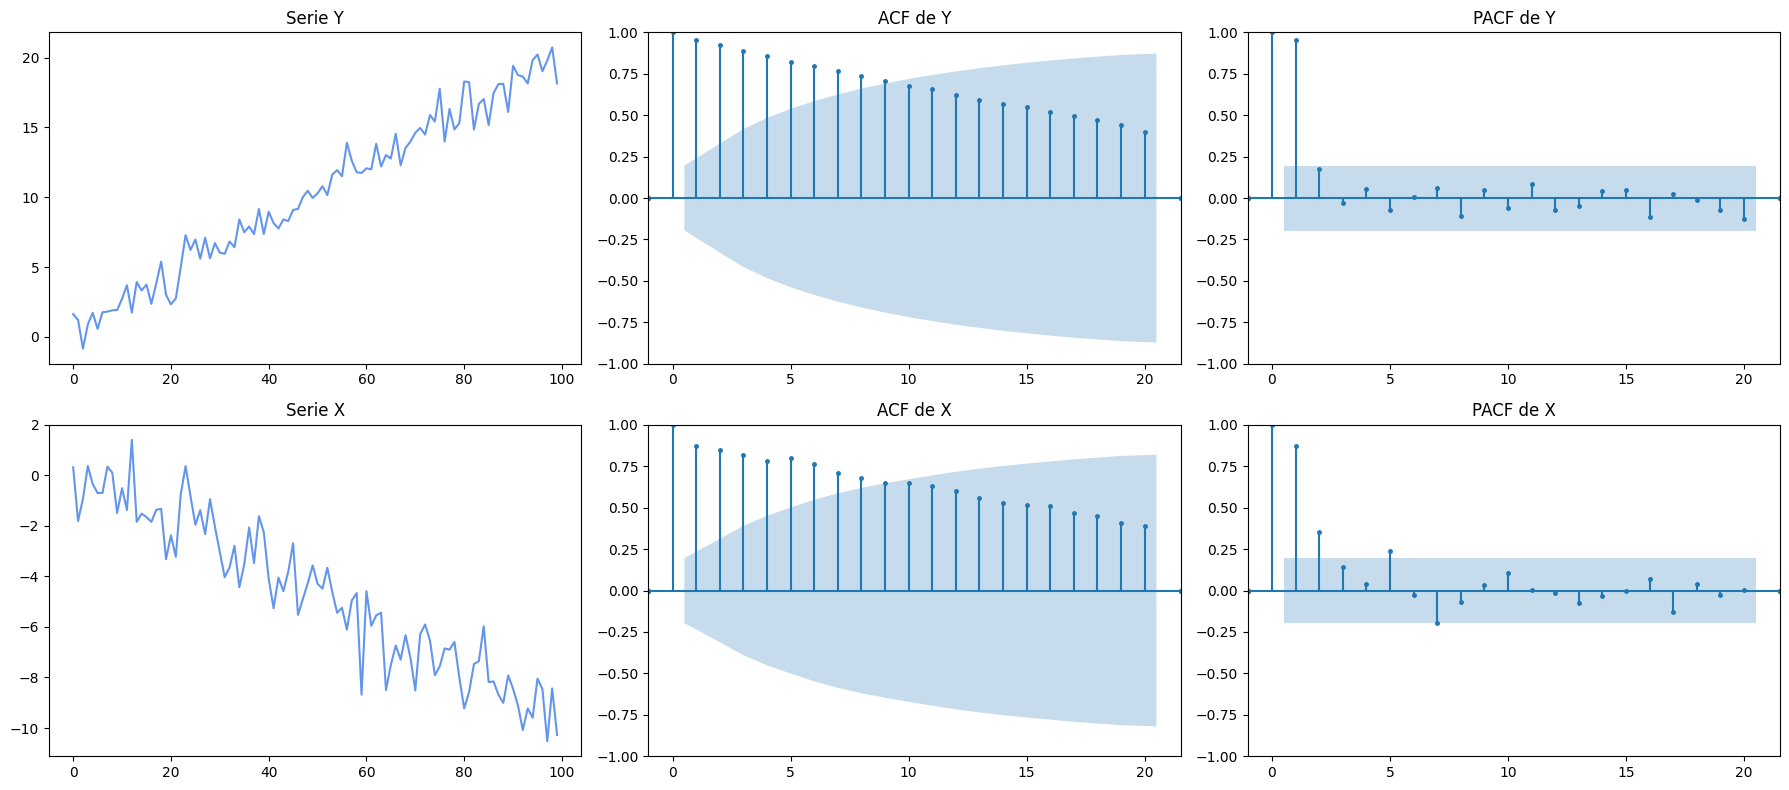

In [3]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

# Primera Fila - Gráficos Y
df['y'].plot(ax=axes[0, 0], title="Serie Y", color='cornflowerblue')
plot_acf(df['y'], ax=axes[0, 1], title="ACF de Y", marker = '.',)
plot_pacf(df['y'], ax=axes[0, 2], title="PACF de Y", marker = '.',)

# Segunda fila - Gráficos X
df['x'].plot(ax=axes[1, 0], title="Serie X", color='cornflowerblue')
plot_acf(df['x'], ax=axes[1, 1], title="ACF de X", marker = '.',)
plot_pacf(df['x'], ax=axes[1, 2], title="PACF de X", marker = '.',)

plt.tight_layout()
plt.show()

In [4]:
# Modelo de regresión de Y en X
reg_directa = smf.ols('y ~ x', data=df).fit()
print(reg_directa.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.862
Method:                 Least Squares   F-statistic:                     617.5
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           4.29e-44
Time:                        07:14:35   Log-Likelihood:                -217.92
No. Observations:                 100   AIC:                             439.8
Df Residuals:                      98   BIC:                             445.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.9995      0.397      5.035      0.0

In [5]:
# Modelo incluyendo la tendencia
modelo_tend = smf.ols('y ~ x + t', data=df).fit()
print(modelo_tend.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.972
Method:                 Least Squares   F-statistic:                     1702.
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           2.93e-76
Time:                        07:14:35   Log-Likelihood:                -138.02
No. Observations:                 100   AIC:                             282.0
Df Residuals:                      97   BIC:                             289.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2885      0.200      1.445      0.1

## **Regresión Espuria Estacionariedad en Diferencias**

In [6]:
# Crearemos dos series estacionarias en diferencias
y2 = np.cumsum(np.random.normal(size=n))
x2 = np.cumsum(np.random.normal(size=n))

df2 = pd.DataFrame({'y2': y2, 'x2': x2})

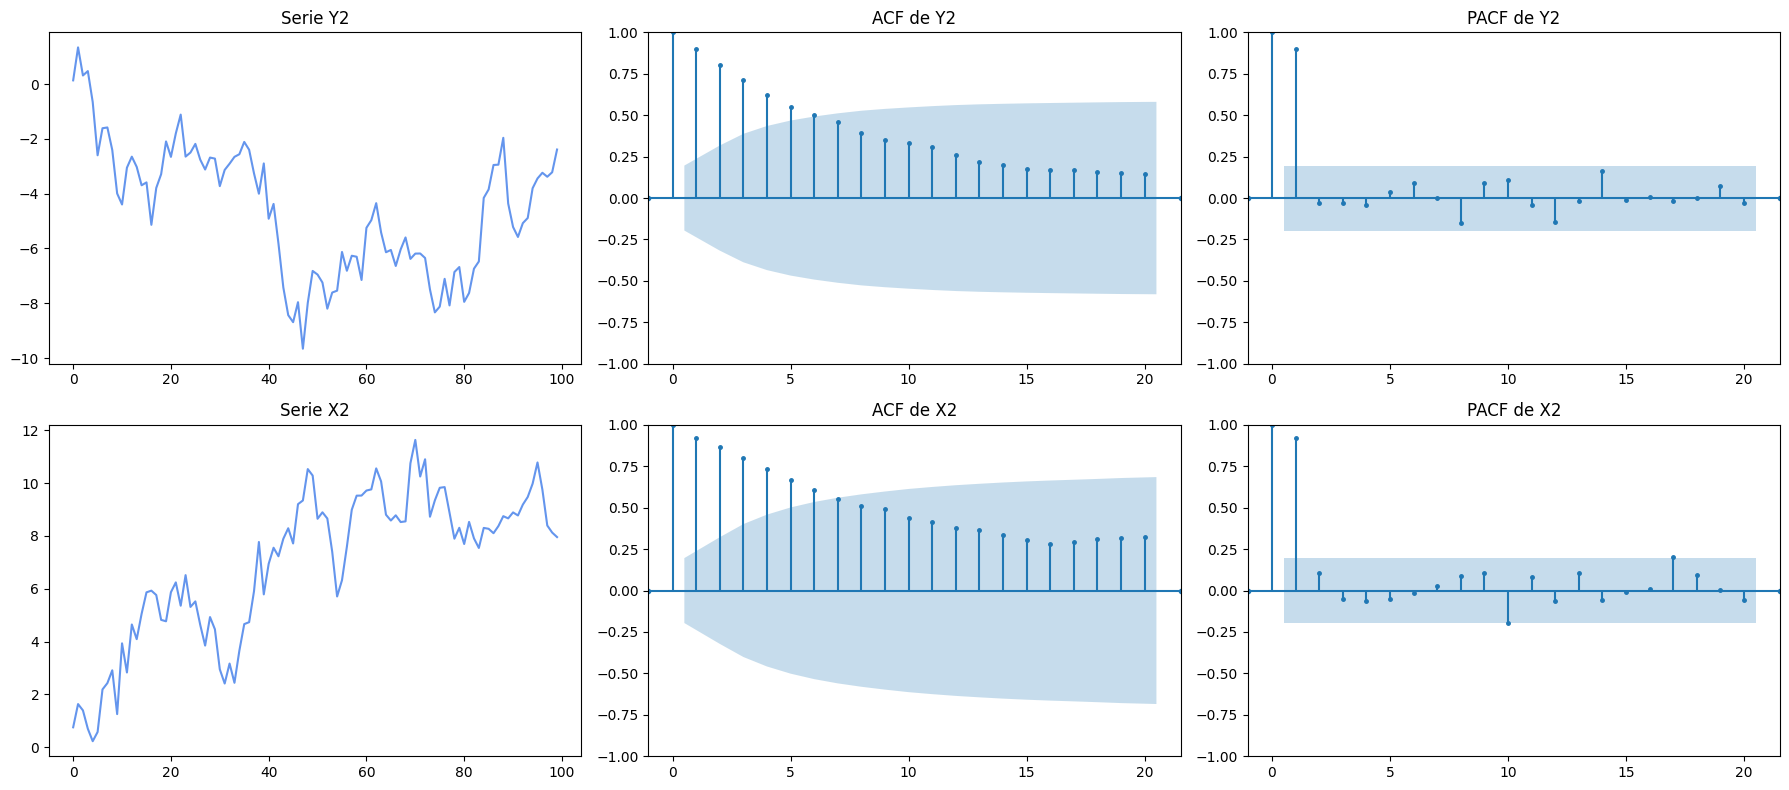

In [7]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

# Primera Fila - Gráficos Y2
df2['y2'].plot(ax=axes[0, 0], title="Serie Y2", color='cornflowerblue')
plot_acf(df2['y2'], ax=axes[0, 1], title="ACF de Y2", marker = '.',)
plot_pacf(df2['y2'], ax=axes[0, 2], title="PACF de Y2", marker = '.',)

# Segunda Fila - Gráficos X2
df2['x2'].plot(ax=axes[1, 0], title="Serie X2", color='cornflowerblue')
plot_acf(df2['x2'], ax=axes[1, 1], title="ACF de X2", marker = '.',)
plot_pacf(df2['x2'], ax=axes[1, 2], title="PACF de X2", marker = '.',)

plt.tight_layout()
plt.show()

In [8]:
# Regresión de Y2 en X2
reg_directa2 = smf.ols('y2 ~ x2', data=df2).fit()
print(reg_directa2.summary())

                            OLS Regression Results                            
Dep. Variable:                     y2   R-squared:                       0.489
Model:                            OLS   Adj. R-squared:                  0.484
Method:                 Least Squares   F-statistic:                     93.77
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           5.89e-16
Time:                        07:14:36   Log-Likelihood:                -193.48
No. Observations:                 100   AIC:                             391.0
Df Residuals:                      98   BIC:                             396.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.5754      0.448     -1.285      0.2

In [9]:
# .diff() para sacar la primera diferencia y .dropna() para eliminar el primer valor nulo (NaN)
df2_dif = df2.diff().dropna()

# Regresión de las diferencias
modelo_dif = smf.ols('y2 ~ x2', data=df2_dif).fit()
print(modelo_dif.summary())

                            OLS Regression Results                            
Dep. Variable:                     y2   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.009
Method:                 Least Squares   F-statistic:                    0.1396
Date:                Sun, 28 Jun 2026   Prob (F-statistic):              0.710
Time:                        07:14:36   Log-Likelihood:                -131.91
No. Observations:                  99   AIC:                             267.8
Df Residuals:                      97   BIC:                             273.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0282      0.093     -0.302      0.7